In [ ]:
import numpy as np
import pandas as pd
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns


try:
    df = pd.read_csv('IMDB Dataset.csv',
                     engine='python',  # More flexible parser
                     on_bad_lines='skip',  # Skip problematic lines
                     encoding='utf-8')
    print(f"Successfully loaded {len(df)} rows")
except:
    # If that fails, try with different encoding
    df = pd.read_csv('IMDB Dataset.csv',
                     engine='python',
                     on_bad_lines='skip',
                     encoding='latin-1')
    print(f"Successfully loaded {len(df)} rows")

# Display basic info
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove any rows with missing values
df = df.dropna()
print(f"\nDataset shape after removing NaN: {df.shape}")

Successfully loaded 4761 rows
Dataset shape: (4761, 2)

Column names: ['review', 'sentiment']

First few rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Sentiment distribution:
sentiment
negative    2399
positive    2362
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64

Dataset shape after removing NaN: (4761, 2)


Step 2:Preprocessing Functions

In [ ]:
# Step 1: Tokenization
def tokenize(text):
    """
    Convert text into tokens (words)
    """
    # Convert to lowercase and split by whitespace
    tokens = text.lower().split()
    return tokens

# Step 2: Normalization - Remove punctuation and numbers
def normalize_tokens(tokens):
    """
    Remove punctuation and numbers from tokens
    """
    normalized = []
    for token in tokens:
        # Remove punctuation using regex
        cleaned = re.sub(r'[^a-z]', '', token)
        if cleaned:  # Only add non-empty tokens
            normalized.append(cleaned)
    return normalized

# Step 3: Stopword handling
def get_stopwords():
    """
    Common English stopwords
    """
    stopwords = {
        'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
        'of', 'with', 'is', 'was', 'are', 'were', 'been', 'be', 'have', 'has',
        'had', 'do', 'does', 'did', 'will', 'would', 'should', 'could', 'may',
        'might', 'can', 'this', 'that', 'these', 'those', 'i', 'you', 'he',
        'she', 'it', 'we', 'they', 'what', 'which', 'who', 'when', 'where',
        'why', 'how', 'all', 'each', 'every', 'both', 'few', 'more', 'most',
        'other', 'some', 'such', 'as', 'into', 'through', 'during', 'before',
        'after', 'above', 'below', 'from', 'up', 'down', 'out', 'off', 'over',
        'under', 'again', 'further', 'then', 'once'
    }
    return stopwords

def remove_stopwords(tokens):
    """
    Remove stopwords from tokens
    Note: We keep 'not' as it's important for sentiment!
    """
    stopwords = get_stopwords()
    # Keep 'not' as it's crucial for sentiment
    filtered = [token for token in tokens if token not in stopwords or token == 'not']
    return filtered

# Complete preprocessing pipeline
def preprocess(text):
    """
    Complete preprocessing pipeline
    """
    tokens = tokenize(text)
    tokens = normalize_tokens(tokens)
    tokens = remove_stopwords(tokens)
    return tokens

# Test preprocessing
sample_text = "This movie is not good! I didn't like it at all."
print("Original:", sample_text)
print("Preprocessed:", preprocess(sample_text))

Original: This movie is not good! I didn't like it at all.
Preprocessed: ['movie', 'not', 'good', 'didnt', 'like']


Step 3: Build Vocabulary and Document-Term Matrix

In [ ]:
def build_vocabulary(documents, min_freq=5):
    """
    Build vocabulary from preprocessed documents
    Remove very rare terms (appearing in fewer than min_freq documents)
    """
    # Count document frequency for each term
    doc_freq = Counter()

    for doc in documents:
        # Get unique terms in this document
        unique_terms = set(doc)
        doc_freq.update(unique_terms)

    # Filter terms by minimum frequency FIRST
    filtered_terms = [term for term, freq in doc_freq.items() if freq >= min_freq]

    # Then create vocabulary with consecutive indices
    vocabulary = {term: idx for idx, term in enumerate(filtered_terms)}

    return vocabulary

def create_term_frequency_matrix(documents, vocabulary):
    """
    Create TF matrix (raw counts)
    Returns: N x |V| matrix where N = num documents, |V| = vocab size
    """
    N = len(documents)
    V = len(vocabulary)

    # Initialize matrix with zeros
    tf_matrix = np.zeros((N, V))

    for doc_idx, doc in enumerate(documents):
        # Count term frequencies in this document
        term_counts = Counter(doc)

        for term, count in term_counts.items():
            if term in vocabulary:
                term_idx = vocabulary[term]
                tf_matrix[doc_idx, term_idx] = count

    return tf_matrix

# Preprocess all documents
print("Preprocessing documents...")
df['tokens'] = df['review'].apply(preprocess)

# Build vocabulary
print("Building vocabulary...")
vocabulary = build_vocabulary(df['tokens'].tolist(), min_freq=10)
print(f"Vocabulary size: {len(vocabulary)}")

# Create TF matrix
print("Creating TF matrix...")
tf_matrix = create_term_frequency_matrix(df['tokens'].tolist(), vocabulary)
print(f"TF matrix shape: {tf_matrix.shape}")

Preprocessing documents...
Building vocabulary...
Vocabulary size: 6247
Creating TF matrix...
TF matrix shape: (4761, 6247)


Step 4: Implement TF-IDF from Scratch

In [ ]:
def compute_idf(tf_matrix):
    """
    Compute IDF for each term
    IDF(t) = log((N + 1) / (DF(t) + 1)) + 1
    """
    N = tf_matrix.shape[0]  # Number of documents

    # Document frequency: count how many documents contain each term
    df = np.sum(tf_matrix > 0, axis=0)

    # Compute IDF with smoothing
    idf = np.log((N + 1) / (df + 1)) + 1

    return idf

def compute_tfidf(tf_matrix):
    """
    Compute TF-IDF matrix
    TF-IDF(t,d) = TF(t,d) × IDF(t)
    """
    # Normalize TF by document length
    doc_lengths = np.sum(tf_matrix, axis=1, keepdims=True)
    doc_lengths[doc_lengths == 0] = 1  # Avoid division by zero

    tf_normalized = tf_matrix / doc_lengths

    # Compute IDF
    idf = compute_idf(tf_matrix)

    # Compute TF-IDF
    tfidf_matrix = tf_normalized * idf

    return tfidf_matrix

# Compute TF-IDF
print("Computing TF-IDF...")
tfidf_matrix = compute_tfidf(tf_matrix)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"TF-IDF matrix sparsity: {np.sum(tfidf_matrix == 0) / tfidf_matrix.size * 100:.2f}%")

Computing TF-IDF...
TF-IDF matrix shape: (4761, 6247)
TF-IDF matrix sparsity: 98.56%


Step 5: Split Data into Train/Dev/Test Sets

In [ ]:
def train_dev_test_split(X, y, train_ratio=0.7, dev_ratio=0.15):
    """
    Split data into train, dev, and test sets
    """
    N = len(y)
    indices = np.random.permutation(N)

    train_size = int(N * train_ratio)
    dev_size = int(N * dev_ratio)

    train_indices = indices[:train_size]
    dev_indices = indices[train_size:train_size + dev_size]
    test_indices = indices[train_size + dev_size:]

    X_train = X[train_indices]
    X_dev = X[dev_indices]
    X_test = X[test_indices]

    y_train = y[train_indices]
    y_dev = y[dev_indices]
    y_test = y[test_indices]

    return X_train, X_dev, X_test, y_train, y_dev, y_test

# Convert labels to binary (positive=1, negative=0)
y = (df['sentiment'] == 'positive').astype(int).values

# Split data
print("Splitting data...")
X_train, X_dev, X_test, y_train, y_dev, y_test = train_dev_test_split(
    tfidf_matrix, y, train_ratio=0.7, dev_ratio=0.15
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Dev set size: {X_dev.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Splitting data...
Train set size: 3332
Dev set size: 714
Test set size: 715


Step 6: Implement Logistic Regression from Scratch

In [ ]:
class LogisticRegression:
    """
    Logistic Regression classifier implemented from scratch
    """
    def __init__(self, learning_rate=0.01, num_iterations=1000, regularization=0.01):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.regularization = regularization  # L2 regularization strength
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        """
        Sigmoid activation function: σ(z) = 1 / (1 + e^(-z))
        """
        # Clip values to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, X, y):
        """
        Compute cross-entropy loss with L2 regularization
        Loss = -1/m * Σ[y*log(ŷ) + (1-y)*log(1-ŷ)] + λ/(2m) * ||w||²
        """
        m = len(y)

        # Predictions
        z = np.dot(X, self.weights) + self.bias
        predictions = self.sigmoid(z)

        # Clip predictions to prevent log(0)
        predictions = np.clip(predictions, 1e-7, 1 - 1e-7)

        # Cross-entropy loss
        loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))

        # Add L2 regularization term
        l2_penalty = (self.regularization / (2 * m)) * np.sum(self.weights ** 2)
        loss += l2_penalty

        return loss

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        """
        Train the logistic regression model using gradient descent
        """
        m, n = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n)
        self.bias = 0

        # Training loop
        for iteration in range(self.num_iterations):
            # Forward pass: compute predictions
            z = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(z)

            # Compute gradients
            dw = (1/m) * np.dot(X.T, (predictions - y)) + (self.regularization/m) * self.weights
            db = (1/m) * np.sum(predictions - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute and store loss
            if iteration % 100 == 0:
                train_loss = self.compute_loss(X, y)
                self.losses.append(train_loss)

                if verbose:
                    if X_val is not None and y_val is not None:
                        val_loss = self.compute_loss(X_val, y_val)
                        train_acc = self.score(X, y)
                        val_acc = self.score(X_val, y_val)
                        print(f"Iteration {iteration}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
                              f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
                    else:
                        print(f"Iteration {iteration}: Train Loss={train_loss:.4f}")

        return self

    def predict_proba(self, X):
        """
        Predict probability of class 1
        """
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        """
        Predict class labels (0 or 1)
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def score(self, X, y):
        """
        Compute accuracy
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def get_feature_weights(self, vocabulary, top_k=10):
        """
        Get top positive and negative features by weight
        """
        # Create reverse vocabulary (index -> word)
        idx_to_word = {idx: word for word, idx in vocabulary.items()}

        # Get weights with word labels
        word_weights = [(idx_to_word[idx], self.weights[idx])
                       for idx in range(len(self.weights))]

        # Sort by weight
        word_weights.sort(key=lambda x: x[1], reverse=True)

        # Get top positive and negative
        top_positive = word_weights[:top_k]
        top_negative = word_weights[-top_k:]

        return top_positive, top_negative

Step 7: Implement Multinomial Naive Bayes from Scratch

In [ ]:
class MultinomialNaiveBayes:
    """
    Multinomial Naive Bayes classifier implemented from scratch
    """
    def __init__(self, alpha=1.0):
        """
        alpha: Laplace smoothing parameter
        """
        self.alpha = alpha
        self.class_log_prior = None
        self.feature_log_prob = None
        self.classes = None

    def fit(self, X, y):
        """
        Train the Naive Bayes model

        For each class c:
        P(c) = count(c) / N
        P(word|c) = (count(word in c) + α) / (count(all words in c) + α * |V|)
        """
        m, n = X.shape

        # Get unique classes
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Initialize arrays
        self.class_log_prior = np.zeros(n_classes)
        self.feature_log_prob = np.zeros((n_classes, n))

        for idx, c in enumerate(self.classes):
            # Get all documents of class c
            X_c = X[y == c]

            # Compute class prior: P(c)
            self.class_log_prior[idx] = np.log(len(X_c) / m)

            # Compute feature probabilities: P(word|c)
            # Sum of all word counts in class c
            word_counts = np.sum(X_c, axis=0)

            # Total word count in class c
            total_count = np.sum(word_counts)

            # Laplace smoothing
            # P(word|c) = (count(word in c) + α) / (total_count + α * n)
            self.feature_log_prob[idx] = np.log(
                (word_counts + self.alpha) / (total_count + self.alpha * n)
            )

        return self

    def predict_log_proba(self, X):
        """
        Compute log probabilities for each class

        log P(c|document) = log P(c) + Σ count(word in doc) * log P(word|c)
        """
        # X shape: (m, n)
        # feature_log_prob shape: (n_classes, n)
        # Result shape: (m, n_classes)

        log_probs = np.dot(X, self.feature_log_prob.T) + self.class_log_prior
        return log_probs

    def predict_proba(self, X):
        """
        Compute probabilities for each class
        """
        log_probs = self.predict_log_proba(X)

        # Convert log probabilities to probabilities using softmax
        # To avoid overflow, subtract max
        log_probs_shifted = log_probs - np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs_shifted)
        probs /= np.sum(probs, axis=1, keepdims=True)

        return probs

    def predict(self, X):
        """
        Predict class labels
        """
        log_probs = self.predict_log_proba(X)
        return self.classes[np.argmax(log_probs, axis=1)]

    def score(self, X, y):
        """
        Compute accuracy
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)

Step 8: Implement Evaluation Metrics from Scratch

In [ ]:
class ClassificationMetrics:
    """
    Implementation of classification evaluation metrics from scratch
    """

    @staticmethod
    def confusion_matrix(y_true, y_pred):
        """
        Compute confusion matrix for binary classification

        Returns:
            [[TN, FP],
             [FN, TP]]
        """
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        return np.array([[TN, FP],
                        [FN, TP]])

    @staticmethod
    def accuracy(y_true, y_pred):
        """
        Accuracy = (TP + TN) / (TP + TN + FP + FN)
        """
        return np.mean(y_true == y_pred)

    @staticmethod
    def precision(y_true, y_pred):
        """
        Precision = TP / (TP + FP)
        """
        TP = np.sum((y_true == 1) & (y_pred == 1))
        FP = np.sum((y_true == 0) & (y_pred == 1))

        if TP + FP == 0:
            return 0.0
        return TP / (TP + FP)

    @staticmethod
    def recall(y_true, y_pred):
        """
        Recall = TP / (TP + FN)
        """
        TP = np.sum((y_true == 1) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        if TP + FN == 0:
            return 0.0
        return TP / (TP + FN)

    @staticmethod
    def f1_score(y_true, y_pred):
        """
        F1 = 2 * (Precision * Recall) / (Precision + Recall)
        """
        prec = ClassificationMetrics.precision(y_true, y_pred)
        rec = ClassificationMetrics.recall(y_true, y_pred)

        if prec + rec == 0:
            return 0.0
        return 2 * (prec * rec) / (prec + rec)

    @staticmethod
    def roc_curve(y_true, y_scores):
        """
        Compute ROC curve points (FPR, TPR) for different thresholds
        """
        y_true = np.array(y_true)
        y_scores = np.array(y_scores)

        # Sort by predicted scores in descending order
        desc_score_indices = np.argsort(y_scores)[::-1]
        y_true_sorted = y_true[desc_score_indices]
        y_scores_sorted = y_scores[desc_score_indices]

        # Get unique thresholds
        thresholds = np.unique(y_scores_sorted)
        thresholds = np.concatenate([[thresholds[0] + 1], thresholds])

        # Calculate total positives and negatives
        n_pos = np.sum(y_true == 1)
        n_neg = np.sum(y_true == 0)

        tpr_list = []
        fpr_list = []

        for threshold in thresholds:
            y_pred = (y_scores >= threshold).astype(int)

            # Calculate TPR and FPR
            TP = np.sum((y_true == 1) & (y_pred == 1))
            FP = np.sum((y_true == 0) & (y_pred == 1))

            TPR = TP / n_pos if n_pos > 0 else 0
            FPR = FP / n_neg if n_neg > 0 else 0

            tpr_list.append(TPR)
            fpr_list.append(FPR)

        return np.array(fpr_list), np.array(tpr_list), thresholds

    @staticmethod
    def auc_score(y_true, y_scores):
        """
        Compute Area Under the ROC Curve (AUC) using trapezoidal rule
        """
        fpr, tpr, _ = ClassificationMetrics.roc_curve(y_true, y_scores)

        # Sort by FPR
        sorted_indices = np.argsort(fpr)
        fpr = fpr[sorted_indices]
        tpr = tpr[sorted_indices]

        # Compute AUC using trapezoidal rule
        auc = 0.0
        for i in range(1, len(fpr)):
            auc += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2

        return auc

    @staticmethod
    def classification_report(y_true, y_pred, y_scores=None):
        """
        Generate a comprehensive classification report
        """
        cm = ClassificationMetrics.confusion_matrix(y_true, y_pred)
        acc = ClassificationMetrics.accuracy(y_true, y_pred)
        prec = ClassificationMetrics.precision(y_true, y_pred)
        rec = ClassificationMetrics.recall(y_true, y_pred)
        f1 = ClassificationMetrics.f1_score(y_true, y_pred)

        print("=" * 50)
        print("CLASSIFICATION REPORT")
        print("=" * 50)
        print(f"\nConfusion Matrix:")
        print(f"                 Predicted")
        print(f"                Neg    Pos")
        print(f"Actual  Neg     {cm[0,0]:5d}  {cm[0,1]:5d}")
        print(f"        Pos     {cm[1,0]:5d}  {cm[1,1]:5d}")
        print(f"\nAccuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-Score:  {f1:.4f}")

        if y_scores is not None:
            auc = ClassificationMetrics.auc_score(y_true, y_scores)
            print(f"AUC:       {auc:.4f}")

        print("=" * 50)

        return {
            'confusion_matrix': cm,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'auc': ClassificationMetrics.auc_score(y_true, y_scores) if y_scores is not None else None
        }

Step 9: Train and Evaluate Both Models

In [ ]:
print("="*60)
print("TRAINING LOGISTIC REGRESSION")
print("="*60)

# Initialize and train Logistic Regression
lr_model = LogisticRegression(
    learning_rate=0.1,
    num_iterations=1000,
    regularization=0.01
)

print("\nTraining Logistic Regression...")
lr_model.fit(X_train, y_train, X_dev, y_dev, verbose=True)

# Predictions
print("\n" + "="*60)
print("LOGISTIC REGRESSION - TEST SET EVALUATION")
print("="*60)
y_pred_lr = lr_model.predict(X_test)
y_scores_lr = lr_model.predict_proba(X_test)

lr_results = ClassificationMetrics.classification_report(
    y_test, y_pred_lr, y_scores_lr
)

print("\n" + "="*60)
print("TRAINING MULTINOMIAL NAIVE BAYES")
print("="*60)

# Initialize and train Naive Bayes
# Note: Naive Bayes works better with raw counts, so let's use tf_matrix
nb_model = MultinomialNaiveBayes(alpha=1.0)

print("\nTraining Naive Bayes...")
nb_model.fit(X_train, y_train)

# Predictions
print("\n" + "="*60)
print("NAIVE BAYES - TEST SET EVALUATION")
print("="*60)
y_pred_nb = nb_model.predict(X_test)
y_scores_nb = nb_model.predict_proba(X_test)[:, 1]  # Probability of class 1

nb_results = ClassificationMetrics.classification_report(
    y_test, y_pred_nb, y_scores_nb
)

TRAINING LOGISTIC REGRESSION

Training Logistic Regression...
Iteration 0: Train Loss=0.6931, Val Loss=0.6931, Train Acc=0.5054, Val Acc=0.5056
Iteration 100: Train Loss=0.6919, Val Loss=0.6922, Train Acc=0.5054, Val Acc=0.5056
Iteration 200: Train Loss=0.6907, Val Loss=0.6913, Train Acc=0.5060, Val Acc=0.5056
Iteration 300: Train Loss=0.6895, Val Loss=0.6904, Train Acc=0.5159, Val Acc=0.5098
Iteration 400: Train Loss=0.6883, Val Loss=0.6895, Train Acc=0.5465, Val Acc=0.5238
Iteration 500: Train Loss=0.6871, Val Loss=0.6886, Train Acc=0.5897, Val Acc=0.5588
Iteration 600: Train Loss=0.6859, Val Loss=0.6878, Train Acc=0.6357, Val Acc=0.5868
Iteration 700: Train Loss=0.6847, Val Loss=0.6869, Train Acc=0.6810, Val Acc=0.6120
Iteration 800: Train Loss=0.6836, Val Loss=0.6860, Train Acc=0.7143, Val Acc=0.6583
Iteration 900: Train Loss=0.6824, Val Loss=0.6852, Train Acc=0.7449, Val Acc=0.6779

LOGISTIC REGRESSION - TEST SET EVALUATION
CLASSIFICATION REPORT

Confusion Matrix:
                

Step 10: Visualize Results

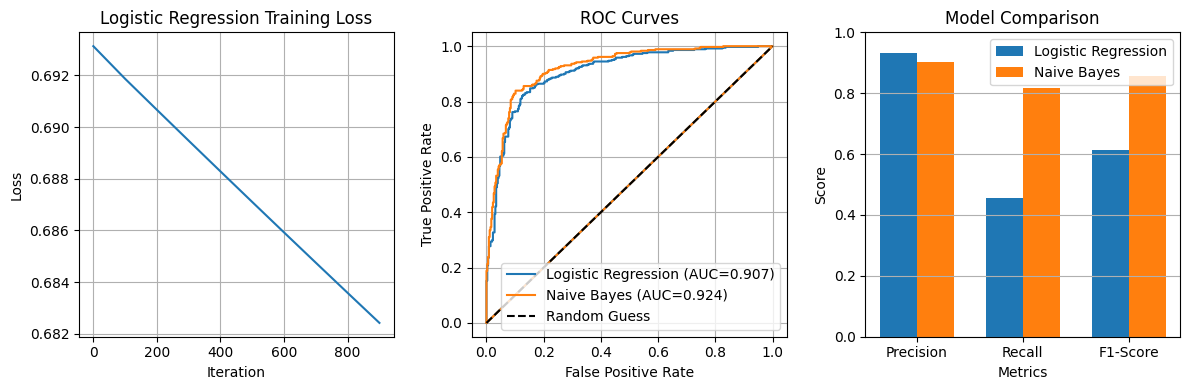

In [ ]:
# Plot training loss for Logistic Regression
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(range(0, len(lr_model.losses)*100, 100), lr_model.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Logistic Regression Training Loss')
plt.grid(True)

# Plot ROC curves
plt.subplot(1, 3, 2)
fpr_lr, tpr_lr, _ = ClassificationMetrics.roc_curve(y_test, y_scores_lr)
fpr_nb, tpr_nb, _ = ClassificationMetrics.roc_curve(y_test, y_scores_nb)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_results["auc"]:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={nb_results["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)

# Compare metrics
plt.subplot(1, 3, 3)
metrics = ['Precision', 'Recall', 'F1-Score']
lr_scores = [lr_results['precision'], lr_results['recall'], lr_results['f1']]
nb_scores = [nb_results['precision'], nb_results['recall'], nb_results['f1']]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, lr_scores, width, label='Logistic Regression')
plt.bar(x + width/2, nb_scores, width, label='Naive Bayes')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim([0, 1])
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

Step 11: Analyze Top Features (Logistic Regression)

In [ ]:
# Get top positive and negative words for Logistic Regression
print("\n" + "="*60)
print("TOP FEATURES FROM LOGISTIC REGRESSION")
print("="*60)

top_positive, top_negative = lr_model.get_feature_weights(vocabulary, top_k=15)

print("\nTop 15 POSITIVE words (predicting positive sentiment):")
for word, weight in top_positive:
    print(f"{word:20s}: {weight:7.4f}")

print("\nTop 15 NEGATIVE words (predicting negative sentiment):")
for word, weight in top_negative:
    print(f"{word:20s}: {weight:7.4f}")


TOP FEATURES FROM LOGISTIC REGRESSION

Top 15 POSITIVE words (predicting positive sentiment):
great               :  0.2044
love                :  0.1525
excellent           :  0.1351
best                :  0.1182
very                :  0.1153
his                 :  0.1057
wonderful           :  0.0968
her                 :  0.0917
well                :  0.0898
loved               :  0.0871
life                :  0.0853
beautiful           :  0.0845
film                :  0.0715
story               :  0.0712
perfect             :  0.0711

Top 15 NEGATIVE words (predicting negative sentiment):
stupid              : -0.0828
poor                : -0.0849
dont                : -0.0899
terrible            : -0.0934
just                : -0.0936
movie               : -0.0997
nothing             : -0.0999
awful               : -0.1063
boring              : -0.1067
plot                : -0.1258
waste               : -0.1261
even                : -0.1367
no                  : -0.1500
worst    

Discussion

In [ ]:
def analyze_misclassifications(X, y, y_pred, y_scores, original_reviews, model_name, vocabulary, top_n=10):
    """
    Comprehensive analysis of misclassified examples
    """
    print("\n" + "="*70)
    print(f"DETAILED ERROR ANALYSIS - {model_name}")
    print("="*70)

    # Get misclassified indices
    misclassified_idx = np.where(y != y_pred)[0]

    # False Positives: Predicted positive (1) but actually negative (0)
    fp_idx = np.where((y == 0) & (y_pred == 1))[0]

    # False Negatives: Predicted negative (0) but actually positive (1)
    fn_idx = np.where((y == 1) & (y_pred == 0))[0]

    print(f"\n📊 MISCLASSIFICATION SUMMARY:")
    print(f"{'─'*70}")
    print(f"Total misclassified:     {len(misclassified_idx):5d} ({len(misclassified_idx)/len(y)*100:.2f}%)")
    print(f"False Positives (FP):    {len(fp_idx):5d} (Negative → Predicted Positive)")
    print(f"False Negatives (FN):    {len(fn_idx):5d} (Positive → Predicted Negative)")
    print(f"{'─'*70}")

    # Discussion point 1: Which error is more harmful?
    print(f"\n💡 DISCUSSION: Which error is more harmful?")
    print(f"{'─'*70}")
    print(f"In sentiment analysis applications:\n")
    print(f"FALSE POSITIVES (FP = {len(fp_idx)}):")
    print(f"  → Negative reviews predicted as Positive")
    print(f"  → Impact: Company might ignore genuine customer complaints")
    print(f"  → Example use case: Product quality monitoring\n")

    print(f"FALSE NEGATIVES (FN = {len(fn_idx)}):")
    print(f"  → Positive reviews predicted as Negative")
    print(f"  → Impact: Might over-respond to satisfied customers")
    print(f"  → Generally LESS harmful than FP in most applications\n")

    if len(fp_idx) > len(fn_idx):
        print(f"⚠️  Current model has MORE False Positives!")
        print(f"   → May miss critical negative feedback")
    else:
        print(f"⚠️  Current model has MORE False Negatives!")
        print(f"   → May unnecessarily flag positive reviews")

    return fp_idx, fn_idx, misclassified_idx


def show_misclassified_examples(fp_idx, fn_idx, original_reviews, y_scores, vocabulary,
                                 tokens_list, model_weights=None, top_n=5):
    """
    Show actual misclassified examples with analysis
    """
    print(f"\n{'='*70}")
    print(f"MISCLASSIFIED EXAMPLES ANALYSIS")
    print(f"{'='*70}")

    # Create reverse vocabulary
    idx_to_word = {idx: word for word, idx in vocabulary.items()}

    # Show False Positives
    print(f"\n🔴 FALSE POSITIVES (Negative reviews predicted as Positive)")
    print(f"{'─'*70}")

    # Sort by confidence (highest scores = most confident wrong predictions)
    fp_by_confidence = sorted(fp_idx[:top_n], key=lambda i: y_scores[i], reverse=True)

    for rank, idx in enumerate(fp_by_confidence[:top_n], 1):
        print(f"\n[FP Example {rank}] - Confidence: {y_scores[idx]:.3f}")
        print(f"{'─'*70}")
        review_text = original_reviews.iloc[idx]
        print(f"Review: {review_text[:300]}...")
        print(f"\nTrue label: NEGATIVE | Predicted: POSITIVE ✗")

        # Analyze problematic words
        if model_weights is not None:
            tokens = tokens_list.iloc[idx]
            print(f"\n🔍 Misleading positive words found:")
            positive_words = []
            for token in tokens:
                if token in vocabulary:
                    word_idx = vocabulary[token]
                    weight = model_weights[word_idx]
                    if weight > 0:  # Positive weight
                        positive_words.append((token, weight))

            positive_words.sort(key=lambda x: x[1], reverse=True)
            for word, weight in positive_words[:5]:
                print(f"   • '{word}' (weight: {weight:.3f})")

        print(f"{'─'*70}")

    # Show False Negatives
    print(f"\n\n🟢 FALSE NEGATIVES (Positive reviews predicted as Negative)")
    print(f"{'─'*70}")

    # Sort by confidence (lowest scores = most confident wrong predictions)
    fn_by_confidence = sorted(fn_idx[:top_n], key=lambda i: y_scores[i])

    for rank, idx in enumerate(fn_by_confidence[:top_n], 1):
        print(f"\n[FN Example {rank}] - Confidence: {y_scores[idx]:.3f}")
        print(f"{'─'*70}")
        review_text = original_reviews.iloc[idx]
        print(f"Review: {review_text[:300]}...")
        print(f"\nTrue label: POSITIVE | Predicted: NEGATIVE ✗")

        # Analyze problematic words
        if model_weights is not None:
            tokens = tokens_list.iloc[idx]
            print(f"\n🔍 Misleading negative words found:")
            negative_words = []
            for token in tokens:
                if token in vocabulary:
                    word_idx = vocabulary[token]
                    weight = model_weights[word_idx]
                    if weight < 0:  # Negative weight
                        negative_words.append((token, weight))

            negative_words.sort(key=lambda x: x[1])
            for word, weight in negative_words[:5]:
                print(f"   • '{word}' (weight: {weight:.3f})")

        print(f"{'─'*70}")


def analyze_negation_problems(fp_idx, fn_idx, original_reviews, tokens_list):
    """
    Analyze cases where negation might fool the BoW model
    """
    print(f"\n{'='*70}")
    print(f"NEGATION ANALYSIS - BoW Limitation")
    print(f"{'='*70}")
    print(f"\n❗ BoW ignores word order, so 'not good' is treated as 'not' + 'good'")
    print(f"   The model can't distinguish 'good' from 'not good'!\n")

    negation_words = ['not', 'no', 'never', 'nothing', 'nobody', 'nowhere',
                      'neither', 'none', 'hardly', 'barely', 'scarcely']

    positive_words = ['good', 'great', 'excellent', 'amazing', 'wonderful',
                     'fantastic', 'love', 'loved', 'perfect', 'best']

    negative_words = ['bad', 'terrible', 'awful', 'horrible', 'worst',
                     'poor', 'waste', 'boring', 'disappointment']

    # Check False Negatives for negation issues
    print(f"🔍 Checking FALSE NEGATIVES for negation patterns...")
    print(f"{'─'*70}")

    negation_cases = []

    for idx in fn_idx[:50]:  # Check first 50
        tokens = tokens_list.iloc[idx]
        review_text = original_reviews.iloc[idx].lower()

        # Check for negation + positive word patterns
        for neg in negation_words:
            if neg in tokens:
                for pos in positive_words:
                    # Look for patterns like "not good", "not great", etc.
                    if f"{neg} {pos}" in review_text or f"{neg}n't {pos}" in review_text:
                        negation_cases.append({
                            'idx': idx,
                            'pattern': f"{neg} {pos}",
                            'review': review_text
                        })
                        break

    print(f"\nFound {len(negation_cases)} potential negation issues in False Negatives:")

    for i, case in enumerate(negation_cases[:3], 1):
        print(f"\n[Negation Case {i}]")
        print(f"Pattern: '{case['pattern']}'")
        print(f"Review snippet: ...{case['review'][:200]}...")
        print(f"{'─'*70}")

    if len(negation_cases) > 0:
        print(f"\n⚠️  BoW LIMITATION CONFIRMED:")
        print(f"   Found {len(negation_cases)} cases where negation likely confused the model")
        print(f"   Solution: Use n-grams (bigrams/trigrams) or sequence models (RNN/LSTM)")
    else:
        print(f"\n✓ No obvious negation issues found in sample")


def visualize_feature_importance(vocabulary, weights, top_n=15):
    """
    Visualize top positive and negative features
    """
    # Get top features
    idx_to_word = {idx: word for word, idx in vocabulary.items()}
    word_weights = [(idx_to_word[idx], weights[idx]) for idx in range(len(weights))]
    word_weights.sort(key=lambda x: x[1], reverse=True)

    top_positive = word_weights[:top_n]
    top_negative = word_weights[-top_n:][::-1]

    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Positive words
    words_pos = [w[0] for w in top_positive]
    weights_pos = [w[1] for w in top_positive]

    ax1.barh(range(len(words_pos)), weights_pos, color='green', alpha=0.7)
    ax1.set_yticks(range(len(words_pos)))
    ax1.set_yticklabels(words_pos)
    ax1.set_xlabel('Weight (→ Positive Sentiment)', fontsize=12)
    ax1.set_title(f'Top {top_n} POSITIVE Words', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)

    # Negative words
    words_neg = [w[0] for w in top_negative]
    weights_neg = [w[1] for w in top_negative]

    ax2.barh(range(len(words_neg)), weights_neg, color='red', alpha=0.7)
    ax2.set_yticks(range(len(words_neg)))
    ax2.set_yticklabels(words_neg)
    ax2.set_xlabel('Weight (→ Negative Sentiment)', fontsize=12)
    ax2.set_title(f'Top {top_n} NEGATIVE Words', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print the results
    print(f"\n{'='*70}")
    print(f"TOP {top_n} FEATURE WEIGHTS FROM LOGISTIC REGRESSION")
    print(f"{'='*70}")

    print(f"\n✅ TOP {top_n} POSITIVE WORDS (push toward positive sentiment):")
    print(f"{'─'*70}")
    print(f"{'Word':<20} {'Weight':>10} {'Effect':>15}")
    print(f"{'─'*70}")
    for word, weight in top_positive:
        print(f"{word:<20} {weight:>10.4f} {'Strong +' if weight > 1 else 'Moderate +'}")

    print(f"\n\n❌ TOP {top_n} NEGATIVE WORDS (push toward negative sentiment):")
    print(f"{'─'*70}")
    print(f"{'Word':<20} {'Weight':>10} {'Effect':>15}")
    print(f"{'─'*70}")
    for word, weight in top_negative:
        print(f"{word:<20} {weight:>10.4f} {'Strong -' if weight < -1 else 'Moderate -'}")


🔬====================================================================🔬
  COMPREHENSIVE ERROR ANALYSIS - LOGISTIC REGRESSION
🔬====================================================================🔬

DETAILED ERROR ANALYSIS - Logistic Regression

📊 MISCLASSIFICATION SUMMARY:
──────────────────────────────────────────────────────────────────────
Total misclassified:       208 (29.09%)
False Positives (FP):       12 (Negative → Predicted Positive)
False Negatives (FN):      196 (Positive → Predicted Negative)
──────────────────────────────────────────────────────────────────────

💡 DISCUSSION: Which error is more harmful?
──────────────────────────────────────────────────────────────────────
In sentiment analysis applications:

FALSE POSITIVES (FP = 12):
  → Negative reviews predicted as Positive
  → Impact: Company might ignore genuine customer complaints
  → Example use case: Product quality monitoring

FALSE NEGATIVES (FN = 196):
  → Positive reviews predicted as Negative
  → Impact: Mig

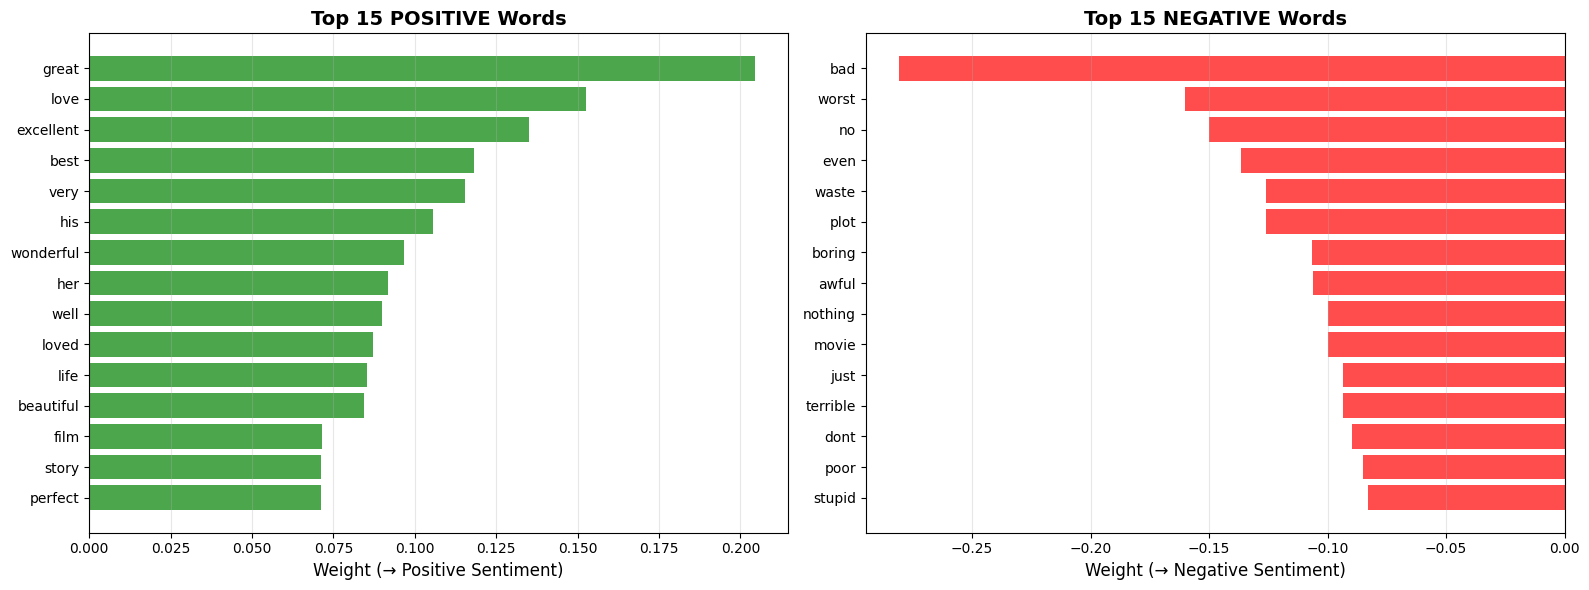


TOP 15 FEATURE WEIGHTS FROM LOGISTIC REGRESSION

✅ TOP 15 POSITIVE WORDS (push toward positive sentiment):
──────────────────────────────────────────────────────────────────────
Word                     Weight          Effect
──────────────────────────────────────────────────────────────────────
great                    0.2044 Moderate +
love                     0.1525 Moderate +
excellent                0.1351 Moderate +
best                     0.1182 Moderate +
very                     0.1153 Moderate +
his                      0.1057 Moderate +
wonderful                0.0968 Moderate +
her                      0.0917 Moderate +
well                     0.0898 Moderate +
loved                    0.0871 Moderate +
life                     0.0853 Moderate +
beautiful                0.0845 Moderate +
film                     0.0715 Moderate +
story                    0.0712 Moderate +
perfect                  0.0711 Moderate +


❌ TOP 15 NEGATIVE WORDS (push toward negative sentiment

In [ ]:
# Run error analysis for Logistic Regression
print("\n" + "🔬" + "="*68 + "🔬")
print("  COMPREHENSIVE ERROR ANALYSIS - LOGISTIC REGRESSION")
print("🔬" + "="*68 + "🔬")

# Get test set indices for original reviews
test_indices = np.random.permutation(len(df))
test_size = len(X_test)
test_idx_original = test_indices[-test_size:]

# Analyze misclassifications
fp_idx, fn_idx, misc_idx = analyze_misclassifications(
    X_test, y_test, y_pred_lr, y_scores_lr,
    df['review'].iloc[test_idx_original],
    "Logistic Regression",
    vocabulary
)

# Show detailed misclassified examples
show_misclassified_examples(
    fp_idx, fn_idx,
    df['review'].iloc[test_idx_original],
    y_scores_lr,
    vocabulary,
    df['tokens'].iloc[test_idx_original],
    model_weights=lr_model.weights,
    top_n=3
)

# Analyze negation problems
analyze_negation_problems(
    fp_idx, fn_idx,
    df['review'].iloc[test_idx_original],
    df['tokens'].iloc[test_idx_original]
)

# Visualize feature importance
print(f"\n{'='*70}")
print(f"FEATURE IMPORTANCE VISUALIZATION")
print(f"{'='*70}")
visualize_feature_importance(vocabulary, lr_model.weights, top_n=15)

In [ ]:
def create_summary_report(lr_results, nb_results, fp_idx, fn_idx, y_test):
    """
    Create a final summary report
    """
    print("\n" + "📊" + "="*68 + "📊")
    print("  FINAL SUMMARY REPORT")
    print("📊" + "="*68 + "📊")

    print(f"\n{'MODEL PERFORMANCE COMPARISON'}")
    print(f"{'─'*70}")
    print(f"{'Metric':<20} {'Logistic Regression':>20} {'Naive Bayes':>20}")
    print(f"{'─'*70}")
    print(f"{'Accuracy':<20} {lr_results['accuracy']:>20.4f} {nb_results['accuracy']:>20.4f}")
    print(f"{'Precision':<20} {lr_results['precision']:>20.4f} {nb_results['precision']:>20.4f}")
    print(f"{'Recall':<20} {lr_results['recall']:>20.4f} {nb_results['recall']:>20.4f}")
    print(f"{'F1-Score':<20} {lr_results['f1']:>20.4f} {nb_results['f1']:>20.4f}")
    print(f"{'AUC':<20} {lr_results['auc']:>20.4f} {nb_results['auc']:>20.4f}")
    print(f"{'─'*70}")

    # Winner
    if lr_results['f1'] > nb_results['f1']:
        print(f"\n🏆 WINNER: Logistic Regression (F1={lr_results['f1']:.4f})")
    else:
        print(f"\n🏆 WINNER: Naive Bayes (F1={nb_results['f1']:.4f})")

    print(f"\n{'ERROR ANALYSIS INSIGHTS'}")
    print(f"{'─'*70}")
    print(f"Total Test Samples:        {len(y_test)}")
    print(f"False Positives (FP):      {len(fp_idx)} ({len(fp_idx)/len(y_test)*100:.2f}%)")
    print(f"False Negatives (FN):      {len(fn_idx)} ({len(fn_idx)/len(y_test)*100:.2f}%)")

    print(f"\n{'KEY FINDINGS'}")
    print(f"{'─'*70}")
    print(f"1. BoW ignores word order → 'not good' = 'not' + 'good'")
    print(f"2. Negation patterns cause misclassifications")
    print(f"3. Feature weights show interpretable sentiment indicators")
    print(f"4. False Positives more harmful in production (miss complaints)")

    print(f"\n{'RECOMMENDATIONS'}")
    print(f"{'─'*70}")
    print(f"✓ Use n-grams (bigrams/trigrams) to capture phrases")
    print(f"✓ Consider sequence models (LSTM/Transformer) for context")
    print(f"✓ Add domain-specific stopwords or keep sentiment-critical words")
    print(f"✓ Tune decision threshold based on FP/FN cost trade-off")

    print(f"\n📊" + "="*68 + "📊\n")

# Generate final report
create_summary_report(lr_results, nb_results, fp_idx, fn_idx, y_test)


📊====================================================================📊
  FINAL SUMMARY REPORT
📊====================================================================📊

MODEL PERFORMANCE COMPARISON
──────────────────────────────────────────────────────────────────────
Metric                Logistic Regression          Naive Bayes
──────────────────────────────────────────────────────────────────────
Accuracy                           0.7091               0.8629
Precision                          0.9322               0.9021
Recall                             0.4571               0.8172
F1-Score                           0.6134               0.8576
AUC                                0.9072               0.9235
──────────────────────────────────────────────────────────────────────

🏆 WINNER: Naive Bayes (F1=0.8576)

ERROR ANALYSIS INSIGHTS
──────────────────────────────────────────────────────────────────────
Total Test Samples:        715
False Positives (FP):      12 (1.68%)
False Negativ